Take a trained wandb run, pick the checkpoint that minimizes rollout **VRMSE**
(`rollout_valid_*/full_VRMSE_T=all_mean`), and evaluate it on a **different** Well dataset.

Outputs:
- a comparison table of **test / rollout_test VRMSE** on the run's **original** test
  set vs the zero-shot dataset
- rollout videos under `_analysis_viz/<run>/zero_shot_<data>/`

Tables use **VRMSE** (cross-run comparable). Avoid the raw wandb scalars `valid` /
`rollout_valid` / `test` / `rollout_test` when comparing CRPS to det — those follow
each run's train `loss_fn` (MAE vs CRPS).

Requires the target data to already be a Well tree (`data/{train,valid,test}` +
`stats.yaml` / `metadata`).


In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys

_cwd = pathlib.Path.cwd().resolve()
REPO_ROOT = next(
    p for p in (_cwd, *_cwd.parents) if (p / "walrus" / "__init__.py").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from walrus.analysis import (
    collect_prediction_values,
    get_run,
    list_data_configs,
    load_data_config,
    run_history,
    select_checkpoint,
    zero_shot,
)

/home/louisa/code/walrus/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configure

Edit these cells, then run the peek + evaluate sections.

In [2]:
# --- wandb run to take the checkpoint from ---
PROJECT = "morphogenesis"
ENTITY = None  # None -> your default wandb entity

# Display name or run id
RUN = "Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001"

# Set only if checkpoints were moved from the path in the run config
CHECKPOINTS_DIR = None

# --- dataset to zero-shot on (Hydra config under walrus/configs/data/) ---
DATA = "morphogenesis_even_skipped_r13"
# Dataset to treat as "original" for the comparison table. Required when the
# run's training path (e.g. processed_morphodynamic_atlas) is no longer on disk.
ORIGINAL_DATA = "morphogenesis_WT"

# Evaluation knobs
FULL = True          # False = short validation subset (faster smoke test)
MAKE_VIDEOS = True
BATCH_SIZE = 1
# None = keep the n_steps_input the run was trained with (recommended)
N_STEPS_INPUT = None
# Also re-eval the same ckpt on the run's original test set for a comparison table
COMPARE_TO_ORIGINAL = True
# How many rollout videos to write (trainer default is 3)
NUM_DETAILED_LOGS = 5

print("available data configs:")
print([c for c in list_data_configs() if "morph" in c.lower() or c in (DATA,)])
print("...", len(list_data_configs()), "total")

available data configs:
['morphogenesis_WT', 'morphogenesis_even_skipped_r13', 'morphogenesis_mit']
... 32 total


## Peek (cheap)

Confirm which checkpoint will be loaded and which data path will be used, before the
expensive eval.

In [3]:
run = get_run(PROJECT, RUN, ENTITY)
sel = select_checkpoint(run, metric="rollout_valid", checkpoints_dir=CHECKPOINTS_DIR)
print(f"run:        {run.name} ({run.id})")
print(f"checkpoint: epoch {sel.epoch}  rollout_valid_VRMSE={sel.value:.4f}")
print(f"            {sel.path}")

data_cfg = load_data_config(DATA)
info = data_cfg.module_parameters.well_dataset_info
print(f"\ndata:       {DATA}")
for name, meta in info.items():
    print(f"  {name}: {meta.get('path')}")

hist = run_history(run)
hist.tail(8)


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/louisa/.netrc.


run:        Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001 (wqvo8a1c)
checkpoint: epoch 35  rollout_valid=0.8203
            /scr/louisa/walrus/runs/morphogenesis_crps/Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001/finetune/2/checkpoints/last

data:       morphogenesis_even_skipped_r13
  morphodynamic_atlas: /data/lcornelis/morphogenesis_data/even-skipped_r13


/home/louisa/code/walrus/.venv/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'morphogenesis_even_skipped_r13': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


,epoch,valid,rollout_valid
27,28,NaN,NaN
28,29,NaN,NaN
29,30,0.153107,0.919538
30,31,NaN,NaN
31,32,NaN,NaN
32,33,NaN,NaN
33,34,NaN,NaN
34,35,0.150683,0.820282


## Run zero-shot eval (+ original comparison)

Loads the best-by-rollout-VRMSE checkpoint, evaluates **test** / **rollout_test VRMSE** on
the run's original test set and on `DATA`, and shows a comparison table. Videos are
only written for the zero-shot leg.


In [4]:
results = zero_shot(
    project=PROJECT,
    run=RUN,
    data=DATA,
    entity=ENTITY,
    full=FULL,
    make_videos=MAKE_VIDEOS,
    checkpoints_dir=CHECKPOINTS_DIR,
    batch_size=BATCH_SIZE,
    n_steps_input=N_STEPS_INPUT,
    compare_to_original=COMPARE_TO_ORIGINAL,
    original_data=ORIGINAL_DATA,
    num_detailed_logs=NUM_DETAILED_LOGS,
)
results["comparison"]

/home/louisa/code/walrus/.venv/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'morphogenesis_WT': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
Failed to load acoustic_scattering_maze dataset
Failed to load acoustic_scattering_inclusions dataset
Failed to load acoustic_scattering_discontinuous dataset
Failed to load active_matter dataset
Failed to load convective_envelope_rsg dataset
Failed to load euler_multi_quadrants_openBC dataset
Failed to load euler_multi_quadrants_periodicBC dataset
Failed to load helmholtz_staircase dataset
Failed to load MHD_64 dataset
Failed to load MHD_256 dataset
Failed to load gray_scott_reaction_diffusion dataset
Failed to load planetswe dataset
Failed to load post_neutron_star_merger dataset
Failed to load rayleigh_benard dataset
Failed to load rayleigh_benard_uniform dataset
Failed to load rayleigh_t

activated learnable rope True
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-

/home/louisa/code/walrus/walrus/trainer/checkpoints.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


output_dir _analysis_viz/Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001/original_morphogenesis_WT/drosophila_wt_sqh_mcherry_piv/rollout_losses/epoch_0_rank0_rollout_test


/home/louisa/code/walrus/.venv/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'morphogenesis_even_skipped_r13': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
Failed to load acoustic_scattering_maze dataset
Failed to load acoustic_scattering_inclusions dataset
Failed to load acoustic_scattering_discontinuous dataset
Failed to load active_matter dataset
Failed to load convective_envelope_rsg dataset
Failed to load euler_multi_quadrants_openBC dataset
Failed to load euler_multi_quadrants_periodicBC dataset
Failed to load helmholtz_staircase dataset
Failed to load MHD_64 dataset
Failed to load MHD_256 dataset
Failed to load gray_scott_reaction_diffusion dataset
Failed to load planetswe dataset
Failed to load post_neutron_star_merger dataset
Failed to load rayleigh_benard dataset
Failed to load rayleigh_benard_uniform dataset
Failed to l

...

_analysis_viz/Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001/zero_shot_morphogenesis_even_skipped_r13/drosophila_even-skipped[r13]_sqh_gfp_piv/rollout_video/epoch0_rank0_rollout_test_batch1_drosophila_even-skipped[r13]_sqh_gfp_piv.mp4


_analysis_viz/Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001/zero_shot_morphogenesis_even_skipped_r13/drosophila_even-skipped[r13]_sqh_gfp_piv/rollout_video/epoch0_rank0_rollout_test_batch2_drosophila_even-skipped[r13]_sqh_gfp_piv.mp4


_analysis_viz/Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001/zero_shot_morphogenesis_even_skipped_r13/drosophila_even-skipped[r13]_sqh_gfp_piv/rollout_video/epoch0_rank0_rollout_test_batch3_drosophila_even-skipped[r13]_sqh_gfp_piv.mp4


_analysis_viz/Walrus_crps_morph_latent-morph-delta-Isotr[Space-Adapt-]-AdamW-0.0001/zero_shot_morphogenesis_even_skipped_r13/drosophila_even-skipped[r13]_sqh_gfp_piv/rollout_video/epoch0_rank0_rollout_test_batch4_drosophila_even-skipped[r13]_sqh_gfp_piv.mp4


,ckpt_epoch,rollout_valid_at_ckpt,eval,data,test,rollout_test
0,25,0.883987,original_test,morphogenesis_WT,0.175164,0.807670
1,25,0.883987,zero_shot,morphogenesis_even_skipped_r13,0.165678,0.810248


## Prediction distributions: original vs zero-shot

Overlay histograms of **model predictions** and **ground truth** on the original test
set vs the zero-shot dataset (same best-by-rollout-VRMSE checkpoint).

With `SPLIT="rollout_test"`, dens. are plotted at rollout horizons **5 / 10 / 20 / 30 / full**
frames (first N predicted frames, pooled over pixels × those frames — not a time-average).
Pred and GT panels for the same field share x/y axis limits within each horizon.


/home/louisa/code/walrus/.venv/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'morphogenesis_WT': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
Failed to load acoustic_scattering_maze dataset
Failed to load acoustic_scattering_inclusions dataset
Failed to load acoustic_scattering_discontinuous dataset
Failed to load active_matter dataset
Failed to load convective_envelope_rsg dataset
Failed to load euler_multi_quadrants_openBC dataset
Failed to load euler_multi_quadrants_periodicBC dataset
Failed to load helmholtz_staircase dataset
Failed to load MHD_64 dataset
Failed to load MHD_256 dataset
Failed to load gray_scott_reaction_diffusion dataset
Failed to load planetswe dataset
Failed to load post_neutron_star_merger dataset
Failed to load rayleigh_benard dataset
Failed to load rayleigh_benard_uniform dataset
Failed to load rayleigh_t

activated learnable rope True
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-

/home/louisa/code/walrus/walrus/trainer/checkpoints.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(
/home/louisa/code/walrus/.venv/lib/python3

activated learnable rope True
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-axis learnable RoPE
Using per-

/home/louisa/code/walrus/walrus/trainer/checkpoints.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


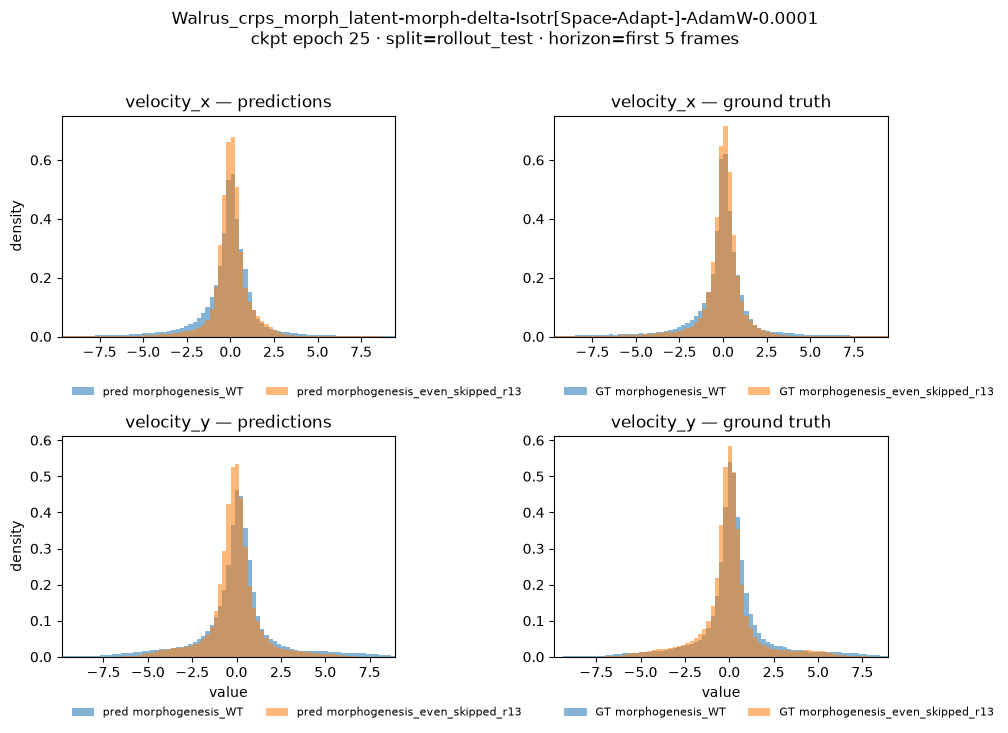

horizon=first 5 frames — prediction histogram L1 (normalized dens.):
  velocity_x: L1=0.2894  (0 = identical dens.)
  velocity_y: L1=0.2785  (0 = identical dens.)



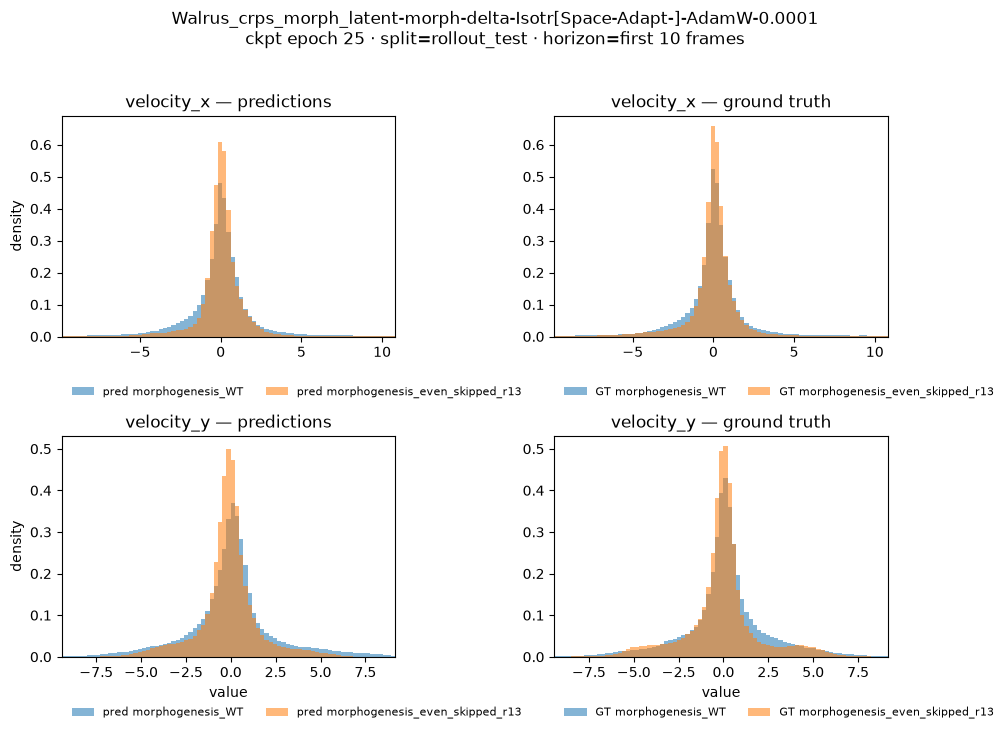

horizon=first 10 frames — prediction histogram L1 (normalized dens.):
  velocity_x: L1=0.2953  (0 = identical dens.)
  velocity_y: L1=0.3095  (0 = identical dens.)



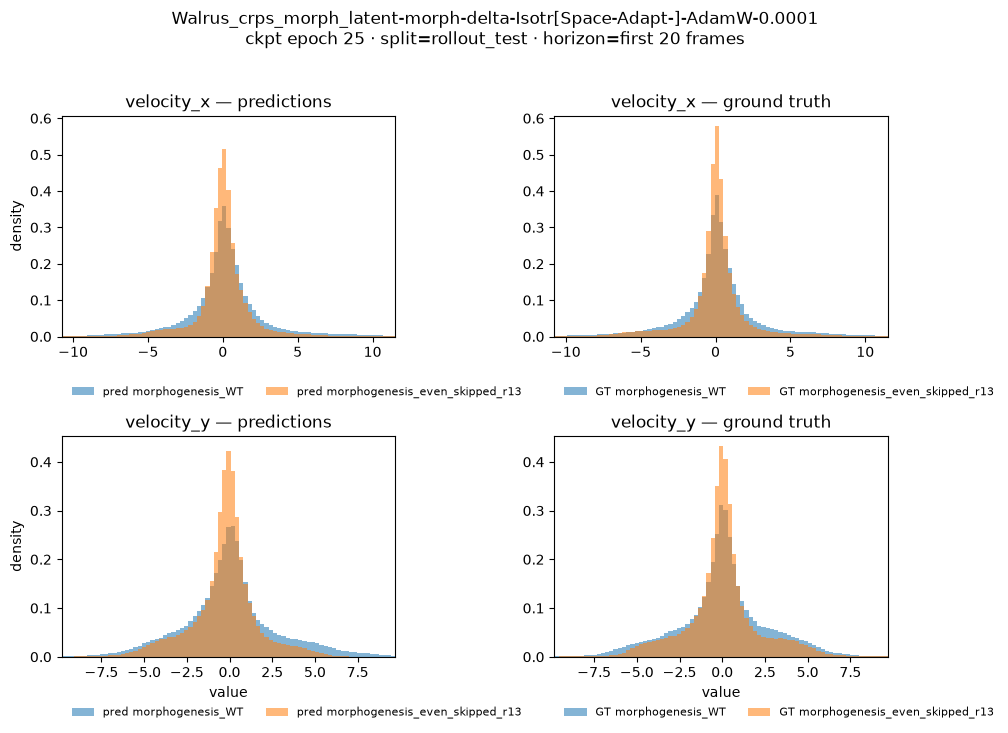

horizon=first 20 frames — prediction histogram L1 (normalized dens.):
  velocity_x: L1=0.3381  (0 = identical dens.)
  velocity_y: L1=0.3110  (0 = identical dens.)



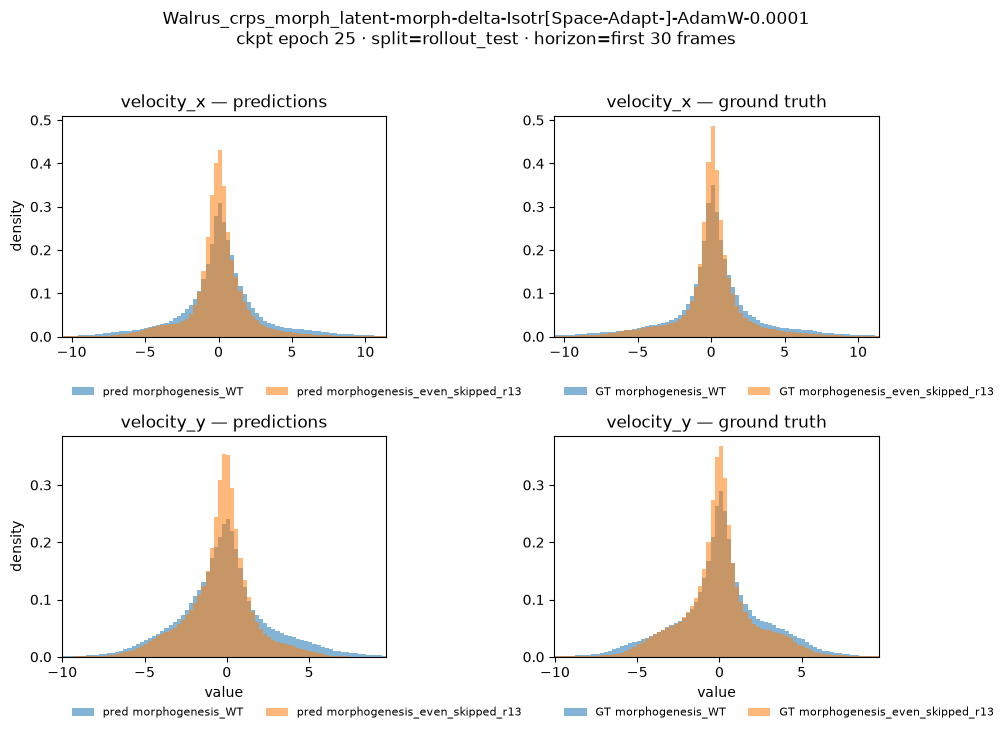

horizon=first 30 frames — prediction histogram L1 (normalized dens.):
  velocity_x: L1=0.3053  (0 = identical dens.)
  velocity_y: L1=0.2778  (0 = identical dens.)



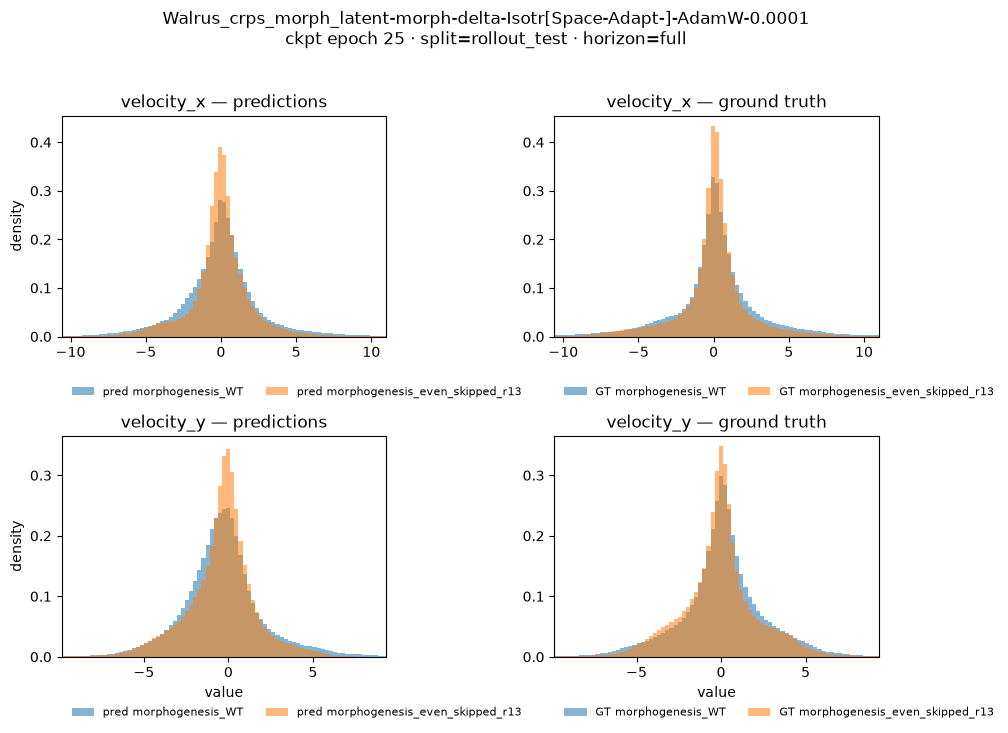

horizon=full — prediction histogram L1 (normalized dens.):
  velocity_x: L1=0.2504  (0 = identical dens.)
  velocity_y: L1=0.1992  (0 = identical dens.)



In [5]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

%matplotlib inline

# One-step: SPLIT="test". Rollout: SPLIT="rollout_test" (slower).
# For rollout, dens. are pooled over the first N frames at each horizon (not time-averaged).
SPLIT = "rollout_test"
FIELDS = ["velocity_x", "velocity_y"]  # None = all fields
MAX_BATCHES = None  # e.g. 20 for a quicker smoke plot
# None = full rollout. Ignored when SPLIT == "test" (single step).
HORIZONS = [5, 10, 20, 30, None]

run = get_run(PROJECT, RUN, ENTITY)
overrides = {"batch_size": BATCH_SIZE}
if N_STEPS_INPUT is not None:
    overrides["n_steps_input"] = N_STEPS_INPUT

horizon_kw = {"horizons": HORIZONS} if SPLIT == "rollout_test" else {}
orig_by_h = collect_prediction_values(
    run,
    data=ORIGINAL_DATA,
    data_overrides=overrides,
    split=SPLIT,
    checkpoints_dir=CHECKPOINTS_DIR,
    max_batches=MAX_BATCHES,
    fields=FIELDS,
    **horizon_kw,
)
zs_by_h = collect_prediction_values(
    run,
    data=DATA,
    data_overrides=overrides,
    split=SPLIT,
    checkpoints_dir=CHECKPOINTS_DIR,
    max_batches=MAX_BATCHES,
    fields=FIELDS,
    **horizon_kw,
)

# Normalize to {horizon_key: dist_dict} whether or not horizons= was used.
if SPLIT == "rollout_test":
    horizon_keys = ["full" if h is None else int(h) for h in HORIZONS]
else:
    orig_by_h = {"1-step": orig_by_h}
    zs_by_h = {"1-step": zs_by_h}
    horizon_keys = ["1-step"]

fields = FIELDS or sorted(
    set(orig_by_h[horizon_keys[0]]["pred"]) | set(zs_by_h[horizon_keys[0]]["pred"])
)
epoch = orig_by_h[horizon_keys[0]]["selection"].epoch

for hkey in horizon_keys:
    orig_dist = orig_by_h[hkey]
    zs_dist = zs_by_h[hkey]
    fig, axes = plt.subplots(len(fields), 2, figsize=(10, 3.6 * len(fields)), squeeze=False)
    l1_scores = {}

    for row, field in enumerate(fields):
        all_vals = np.concatenate(
            [
                orig_dist["pred"][field],
                zs_dist["pred"][field],
                orig_dist["ref"][field],
                zs_dist["ref"][field],
            ]
        )
        lo, hi = np.quantile(all_vals, [0.001, 0.999])
        bins = np.linspace(lo, hi, 80)

        ax_pred = axes[row, 0]
        ax_gt = axes[row, 1]

        n_pred_wt, _, _ = ax_pred.hist(
            orig_dist["pred"][field],
            bins=bins,
            density=True,
            alpha=0.55,
            label=f"pred {ORIGINAL_DATA}",
        )
        n_pred_zs, _, _ = ax_pred.hist(
            zs_dist["pred"][field],
            bins=bins,
            density=True,
            alpha=0.55,
            label=f"pred {DATA}",
        )
        ax_pred.set_title(f"{field} — predictions")
        ax_pred.legend(
            fontsize=8, loc="upper left", bbox_to_anchor=(0.0, -0.18), ncol=2, frameon=False
        )
        ax_pred.set_ylabel("density")

        n_gt_wt, _, _ = ax_gt.hist(
            orig_dist["ref"][field],
            bins=bins,
            density=True,
            alpha=0.55,
            label=f"GT {ORIGINAL_DATA}",
        )
        n_gt_zs, _, _ = ax_gt.hist(
            zs_dist["ref"][field],
            bins=bins,
            density=True,
            alpha=0.55,
            label=f"GT {DATA}",
        )
        ax_gt.set_title(f"{field} — ground truth")
        ax_gt.legend(
            fontsize=8, loc="upper left", bbox_to_anchor=(0.0, -0.18), ncol=2, frameon=False
        )

        ymax = max(n_pred_wt.max(), n_pred_zs.max(), n_gt_wt.max(), n_gt_zs.max()) * 1.05
        for ax in (ax_pred, ax_gt):
            ax.set_xlim(bins[0], bins[-1])
            ax.set_ylim(0, ymax)

        p0, _ = np.histogram(orig_dist["pred"][field], bins=bins, density=True)
        p1, _ = np.histogram(zs_dist["pred"][field], bins=bins, density=True)
        l1_scores[field] = float(np.abs(p0 - p1).sum() * (bins[1] - bins[0]))

    axes[-1, 0].set_xlabel("value")
    axes[-1, 1].set_xlabel("value")
    h_label = f"first {hkey} frames" if hkey != "full" and hkey != "1-step" else hkey
    fig.suptitle(
        f"{RUN}\nckpt epoch {epoch} · split={SPLIT} · horizon={h_label}",
        y=1.02,
    )
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.45)
    display(fig)
    plt.close(fig)

    print(f"horizon={h_label} — prediction histogram L1 (normalized dens.):")
    for field, l1 in l1_scores.items():
        print(f"  {field}: L1={l1:.4f}  (0 = identical dens.)")
    print()


## Tips

- Swap `RUN` / `DATA` and re-run the peek + eval cells — no new shell scripts needed.
- Add a new dataset by dropping a yaml in `walrus/configs/data/` (see `morphogenesis_WT.yaml`).
- For a quick smoke test set `FULL = False` and/or `MAKE_VIDEOS = False`.
- If the run used globalnorm, the target Well root needs a `stats.yaml`.